# Retail Sales & Profit Analytics


## Introduction
### Project Overview

Retail businesses generate large amounts of sales data that can provide valuable insights into customer behavior, product performance, revenue trends, and profitability. This project focuses on analyzing retail sales data to uncover meaningful patterns and trends that can support strategic business decisions.

Using Python-based data analysis techniques, the project performs data cleaning, exploratory data analysis (EDA), and visualization to understand sales performance across different customer segments, regions, product categories, and time periods.

The analysis helps identify key revenue drivers, profitable areas, and opportunities for business improvement.

## Import Libraries

In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


## Load Dataset

In [5]:
df = pd.read_csv(r"C:\Users\acer\Downloads\Retail Sales Analytics\global_super_store_orders.tsv", sep="\t")

## Data Understanding

In this section, we examine the structure and quality of the dataset by reviewing its dimensions, columns, data types, summary statistics, missing values, and duplicate records.

## Dataset Preview
The first few records of the dataset are displayed to understand the structure and contents of the data.

In [6]:
df.head()

,Unnamed: 0,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,City,...,Product ID,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit,Shipping Cost,Order Priority
0,35180,29165,IN-2014-24531,8/15/14,8/19/14,Standard Class,AS-10285,Alejandro Savely,Corporate,Guangzhou,...,OFF-SU-10001343,Office Supplies,Supplies,"Elite Scissors, High Speed","45,06",2,0,"5,4","3,53",Medium
1,39850,39615,CA-2014-130904,4/12/14,4/17/14,Standard Class,HM-14980,Henry MacAllister,Consumer,Burlington,...,OFF-AR-10000127,Office Supplies,Art,Newell 321,"20,992",8,"0,2","2,3616","2,28",Medium
2,41575,39158,CA-2012-142993,10/12/12,10/17/12,Standard Class,KA-16525,Kelly Andreada,Consumer,Seattle,...,TEC-AC-10003038,Technology,Accessories,Kingston Digital DataTraveler 16GB USB 2.0,"17,9",2,0,"3,401","1,91",Medium
3,12393,2193,MX-2013-169502,6/13/13,6/15/13,Second Class,AJ-10960,Astrea Jones,Consumer,Santo Domingo,...,TEC-AC-10001341,Technology,Accessories,"Enermax Memory Card, USB","183,36",3,"0,2","22,92","25,54",Critical
4,45530,23217,IN-2014-50627,9/14/14,9/18/14,Standard Class,LW-16825,Laurel Workman,Corporate,Jinhua,...,OFF-EN-10001977,Office Supplies,Envelopes,"Cameo Business Envelopes, Recycled","31,5",2,0,"6,9","1,14",Medium


In [20]:
df.tail()

,Unnamed: 0,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,City,...,Product ID,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit,Shipping Cost,Order Priority
995,48796,36853,CA-2012-125066,12/14/12,12/18/12,Standard Class,KD-16495,Keith Dawkins,Corporate,Jackson,...,FUR-FU-10003829,Furniture,Furnishings,Stackable Trays,"6,16",2,0,"1,9712","0,59",High
996,45222,51024,NI-2011-1810,11/21/11,11/23/11,Second Class,RF-9840,Roy Französisch,Consumer,Kano,...,OFF-SME-10003134,Office Supplies,Storage,"Smead Box, Single Width","6,48",2,"0,7","-9,54","1,2",Critical
997,24301,30969,ID-2013-85732,12/18/13,12/23/13,Second Class,TG-21640,Trudy Glocke,Consumer,Gold Coast,...,TEC-AC-10003626,Technology,Accessories,"Enermax Numeric Keypad, Bluetooth","68,796",2,"0,4","-41,304","8,69",Medium
998,39581,28335,IN-2014-40932,9/25/14,9/30/14,Standard Class,TG-21640,Trudy Glocke,Consumer,Bhiwandi,...,OFF-EN-10001975,Office Supplies,Envelopes,"Kraft Business Envelopes, Security-Tint","32,88",2,0,"4,26","2,34",High
999,41858,37924,CA-2011-138513,5/23/11,5/27/11,Standard Class,EH-13990,Erica Hackney,Consumer,Bellevue,...,OFF-PA-10003177,Office Supplies,Paper,Xerox 1999,"12,96",2,0,"6,2208","1,85",High


## Dataset Shape
The dataset dimensions are checked to determine the number of rows and columns present.

In [7]:
df.shape

(1000, 25)

## Column Names

The available columns in the dataset are displayed to understand the different attributes available for analysis.

In [8]:
df.columns

Index(['Unnamed: 0', 'Row ID', 'Order ID', 'Order Date', 'Ship Date',
       'Ship Mode', 'Customer ID', 'Customer Name', 'Segment', 'City', 'State',
       'Country', 'Postal Code', 'Market', 'Region', 'Product ID', 'Category',
       'Sub-Category', 'Product Name', 'Sales', 'Quantity', 'Discount',
       'Profit', 'Shipping Cost', 'Order Priority'],
      dtype='str')

## Dataset Information
The dataset information is examined to identify column names, data types, and the presence of missing values.

In [9]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 25 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Unnamed: 0      1000 non-null   int64  
 1   Row ID          1000 non-null   int64  
 2   Order ID        1000 non-null   str    
 3   Order Date      1000 non-null   str    
 4   Ship Date       1000 non-null   str    
 5   Ship Mode       1000 non-null   str    
 6   Customer ID     1000 non-null   str    
 7   Customer Name   1000 non-null   str    
 8   Segment         1000 non-null   str    
 9   City            1000 non-null   str    
 10  State           1000 non-null   str    
 11  Country         1000 non-null   str    
 12  Postal Code     196 non-null    float64
 13  Market          1000 non-null   str    
 14  Region          1000 non-null   str    
 15  Product ID      1000 non-null   str    
 16  Category        1000 non-null   str    
 17  Sub-Category    1000 non-null   str    
 18  

## Statistical Summary
A statistical summary is generated to understand numerical columns such as sales, quantity, discount, and profit.

In [11]:
df.describe()

,Unnamed: 0,Row ID,Postal Code,Quantity
count,1000.000000,1000.000000,196.000000,1000.000000
mean,25761.207000,25571.221000,53873.683673,3.388000
std,14723.570956,14570.032549,32754.423804,2.168908
min,41.000000,19.000000,1841.000000,1.000000
25%,13472.500000,13678.250000,19569.000000,2.000000
50%,25680.500000,25229.000000,48230.500000,3.000000
75%,38371.000000,38116.750000,90005.000000,4.000000
max,51243.000000,51285.000000,98502.000000,14.000000


In [10]:
df.describe(include="object")

C:\Users\acer\AppData\Local\Temp\ipykernel_5860\702825166.py:1: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  df.describe(include="object")


,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,City,State,Country,...,Region,Product ID,Category,Sub-Category,Product Name,Sales,Discount,Profit,Shipping Cost,Order Priority
count,1000,1000,1000,1000,1000,1000,1000,1000,1000,1000,...,1000,1000,1000,1000,1000,1000,1000,1000,1000,1000
unique,979,653,689,4,654,552,3,633,382,90,...,13,957,3,17,827,953,21,921,865,4
top,CA-2014-164378,11/4/14,11/9/14,Standard Class,GT-14710,Greg Tran,Consumer,New York City,California,United States,...,Central,OFF-BIN-10000837,Office Supplies,Binders,"Binney & Smith Canvas, Fluorescent","12,96",0,0,"0,87",Medium
freq,2,6,5,585,6,6,536,21,38,196,...,225,3,620,121,5,3,564,12,5,598


## Checking Missing Values
Missing values are identified to ensure data quality before performing analysis.

In [12]:
df.isnull().sum()

Unnamed: 0          0
Row ID              0
Order ID            0
Order Date          0
Ship Date           0
Ship Mode           0
Customer ID         0
Customer Name       0
Segment             0
City                0
State               0
Country             0
Postal Code       804
Market              0
Region              0
Product ID          0
Category            0
Sub-Category        0
Product Name        0
Sales               0
Quantity            0
Discount            0
Profit              0
Shipping Cost       0
Order Priority      0
dtype: int64

In [ ]:
# Checking Duplicate Records
##Description

Duplicate records are checked and removed to maintain data accuracy.

In [13]:
df.duplicated().sum()     #Finds duplicate rows that could affect analysis.

np.int64(0)

## Data Cleaning
Data cleaning is performed to prepare the dataset for analysis by correcting data types, handling missing values, removing duplicates, and creating additional features.

In [14]:
df = df.drop(columns=["Postal Code", "Unnamed: 0"])

In [15]:
df.columns

Index(['Row ID', 'Order ID', 'Order Date', 'Ship Date', 'Ship Mode',
       'Customer ID', 'Customer Name', 'Segment', 'City', 'State', 'Country',
       'Market', 'Region', 'Product ID', 'Category', 'Sub-Category',
       'Product Name', 'Sales', 'Quantity', 'Discount', 'Profit',
       'Shipping Cost', 'Order Priority'],
      dtype='str')

In [16]:
df.head()

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,City,State,...,Product ID,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit,Shipping Cost,Order Priority
0,29165,IN-2014-24531,8/15/14,8/19/14,Standard Class,AS-10285,Alejandro Savely,Corporate,Guangzhou,Guangdong,...,OFF-SU-10001343,Office Supplies,Supplies,"Elite Scissors, High Speed","45,06",2,0,"5,4","3,53",Medium
1,39615,CA-2014-130904,4/12/14,4/17/14,Standard Class,HM-14980,Henry MacAllister,Consumer,Burlington,North Carolina,...,OFF-AR-10000127,Office Supplies,Art,Newell 321,"20,992",8,"0,2","2,3616","2,28",Medium
2,39158,CA-2012-142993,10/12/12,10/17/12,Standard Class,KA-16525,Kelly Andreada,Consumer,Seattle,Washington,...,TEC-AC-10003038,Technology,Accessories,Kingston Digital DataTraveler 16GB USB 2.0,"17,9",2,0,"3,401","1,91",Medium
3,2193,MX-2013-169502,6/13/13,6/15/13,Second Class,AJ-10960,Astrea Jones,Consumer,Santo Domingo,Santo Domingo,...,TEC-AC-10001341,Technology,Accessories,"Enermax Memory Card, USB","183,36",3,"0,2","22,92","25,54",Critical
4,23217,IN-2014-50627,9/14/14,9/18/14,Standard Class,LW-16825,Laurel Workman,Corporate,Jinhua,Zhejiang,...,OFF-EN-10001977,Office Supplies,Envelopes,"Cameo Business Envelopes, Recycled","31,5",2,0,"6,9","1,14",Medium


In [17]:
df[['Sales', 'Profit', 'Shipping Cost', 'Discount']].head(10)

,Sales,Profit,Shipping Cost,Discount
0,"45,06","5,4","3,53",0
1,"20,992","2,3616","2,28","0,2"
2,"17,9","3,401","1,91",0
3,"183,36","22,92","25,54","0,2"
4,"31,5","6,9","1,14",0
5,"98,4","42,3","5,29",0
6,"338,94","101,64","87,72",0
7,"14,4","6,18","0,45",0
8,"344,372","-93,4724","19,76","0,3"
9,"707,52","297,12","58,83",0


In [18]:
df[['Order Date', 'Ship Date']].head(10)

,Order Date,Ship Date
0,8/15/14,8/19/14
1,4/12/14,4/17/14
2,10/12/12,10/17/12
3,6/13/13,6/15/13
4,9/14/14,9/18/14
5,10/22/13,10/27/13
6,8/15/11,8/15/11
7,10/25/14,10/29/14
8,4/19/13,4/24/13
9,5/16/13,5/22/13


## Convert Numeric Columns

The Sales, Profit, Discount, and Shipping Cost columns are stored as text with commas as decimal separators. These columns are converted to numeric format for analysis.

In [19]:
numeric_columns = ['Sales', 'Profit', 'Shipping Cost', 'Discount']

for col in numeric_columns:
    df[col] = df[col].str.replace(',', '.', regex = False).astype(float)

In [20]:
df.dtypes

Row ID              int64
Order ID              str
Order Date            str
Ship Date             str
Ship Mode             str
Customer ID           str
Customer Name         str
Segment               str
City                  str
State                 str
Country               str
Market                str
Region                str
Product ID            str
Category              str
Sub-Category          str
Product Name          str
Sales             float64
Quantity            int64
Discount          float64
Profit            float64
Shipping Cost     float64
Order Priority        str
dtype: object

## Convert Date Columns
The Order Date and Ship Date columns are converted from string format to datetime format to enable time-based analysis.

In [21]:
df['Order Date'] = pd.to_datetime(df['Order Date'], format='%m/%d/%y')
df['Ship Date']= pd.to_datetime(df['Ship Date'], format='%m/%d/%y')

In [22]:
df.dtypes

Row ID                     int64
Order ID                     str
Order Date        datetime64[us]
Ship Date         datetime64[us]
Ship Mode                    str
Customer ID                  str
Customer Name                str
Segment                      str
City                         str
State                        str
Country                      str
Market                       str
Region                       str
Product ID                   str
Category                     str
Sub-Category                 str
Product Name                 str
Sales                    float64
Quantity                   int64
Discount                 float64
Profit                   float64
Shipping Cost            float64
Order Priority               str
dtype: object

In [23]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 23 columns):
 #   Column          Non-Null Count  Dtype         
---  ------          --------------  -----         
 0   Row ID          1000 non-null   int64         
 1   Order ID        1000 non-null   str           
 2   Order Date      1000 non-null   datetime64[us]
 3   Ship Date       1000 non-null   datetime64[us]
 4   Ship Mode       1000 non-null   str           
 5   Customer ID     1000 non-null   str           
 6   Customer Name   1000 non-null   str           
 7   Segment         1000 non-null   str           
 8   City            1000 non-null   str           
 9   State           1000 non-null   str           
 10  Country         1000 non-null   str           
 11  Market          1000 non-null   str           
 12  Region          1000 non-null   str           
 13  Product ID      1000 non-null   str           
 14  Category        1000 non-null   str           
 15  Sub-Category    

## Feature Engineering

In this section, new columns are created from the Order Date to enable time-based analysis, such as monthly sales trends, yearly performance, and quarterly comparisons.

In [61]:
df['Year'] = df['Order Date'].dt.year
df['Month'] = df['Order Date'].dt.month
df['Month Name'] = df['Order Date'].dt.month_name()
df['Quarter'] = df['Order Date'].dt.quarter
df['Day'] = df['Order Date'].dt.day_name()

In [25]:
df[['Order Date', 'Year', 'Month', 'Month Name', 'Quarter', 'Day']].head()

,Order Date,Year,Month,Month Name,Quarter,Day
0,2014-08-15,2014,8,August,3,Friday
1,2014-04-12,2014,4,April,2,Saturday
2,2012-10-12,2012,10,October,4,Friday
3,2013-06-13,2013,6,June,2,Thursday
4,2014-09-14,2014,9,September,3,Sunday


# Exploratory Data Analysis (EDA)
Exploratory Data Analysis is performed to understand sales patterns, customer behavior, product performance, regional trends, and profitability. Various statistical summaries and visualizations are used to identify meaningful business insights.

## Overall Business Performance

In this section, we calculate the key performance indicators (KPIs) to understand the overall business performance.

In [27]:
total_sales = df['Sales'].sum()
total_profit = df['Profit'].sum()
total_orders = df['Order ID'].nunique()
total_customers = df['Customer ID'].nunique()

print(f"Total Sales: {total_sales:,.2f}")
print(f"Total Profit: {total_profit:,.2f}")
print(f"Total Orders: {total_orders}")
print(f"Total Customers: {total_customers}")



Total Sales: 243,960.06
Total Profit: 28,009.23
Total Orders: 979
Total Customers: 654


# Sales by Category

Analyze which product category generates the highest sales.

In [29]:
category_sales = df.groupby('Category')['Sales'].sum().sort_values(ascending=False)
category_sales

Category
Furniture          86018.56200
Technology         81129.40932
Office Supplies    76812.09160
Name: Sales, dtype: float64

# Sales by Category Graph Plot
Identify which product categories generate the highest revenue.

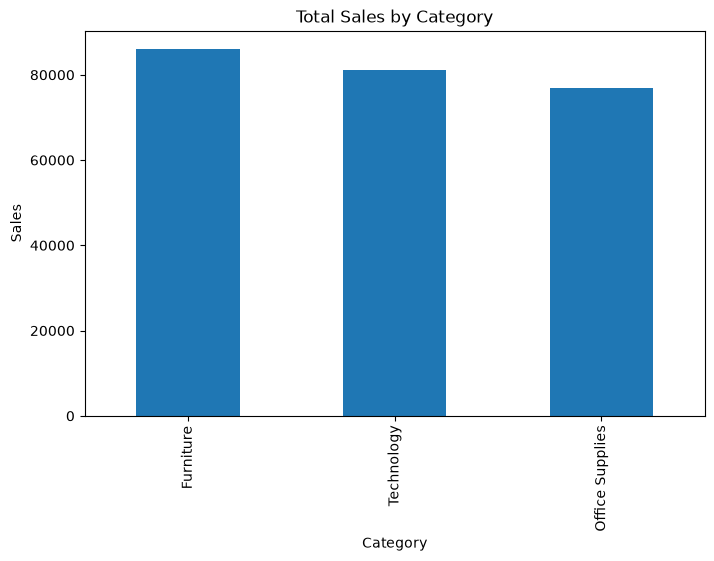

In [30]:
plt.figure(figsize = (8, 5))
category_sales.plot(kind='bar')

plt.title("Total Sales by Category")
plt.xlabel("Category")
plt.ylabel("Sales")

plt.show()

# Profit by Category



In [31]:
category_profit = df.groupby('Category')['Profit'].sum().sort_values(ascending=False)
category_profit

Category
Technology         11938.71242
Furniture          10773.65400
Office Supplies     5296.86650
Name: Profit, dtype: float64

# Profit by Category Graph Plot 

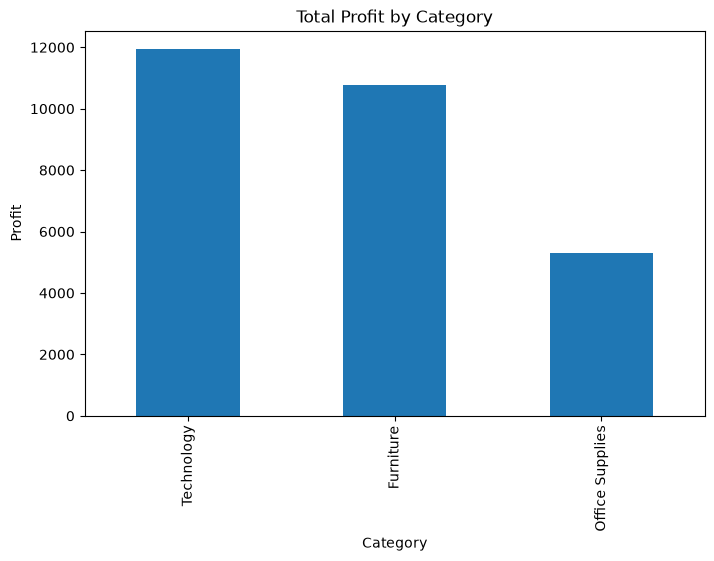

In [33]:
plt.figure(figsize=(8, 5))
category_profit.plot(kind='bar')

plt.title("Total Profit by Category")
plt.xlabel("Category")
plt.ylabel("Profit")

plt.show()

# Sales by Region

In [35]:
region_sales = df.groupby('Region')['Sales'].sum().sort_values(ascending=False)
region_sales

Region
Central           66531.34682
South             25425.25876
North             20774.04624
Central Asia      17393.01000
EMEA              17315.16000
North Asia        17014.39200
Africa            16464.00300
East              13793.57000
Southeast Asia    13401.73110
Oceania           13186.44300
West              10873.80800
Canada             6454.86000
Caribbean          5332.43400
Name: Sales, dtype: float64

# Sales by Region Graph Plot

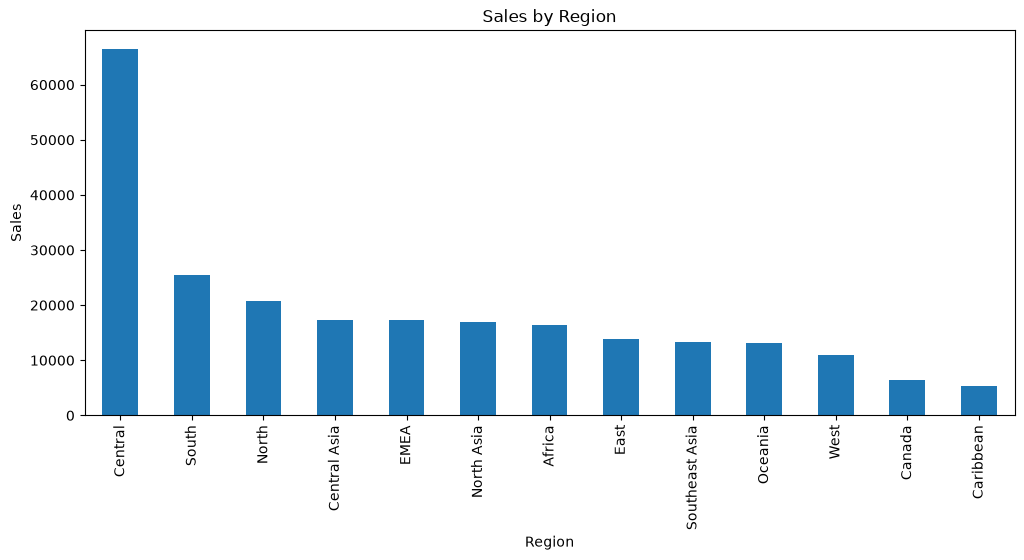

In [40]:
plt.figure(figsize=(12,5))
region_sales.plot(kind='bar')

plt.title("Sales by Region")
plt.xlabel("Region")
plt.ylabel("Sales")

plt.show()
          

# Profit by Region



In [42]:
region_profit= df.groupby('Region')['Profit'].sum().sort_values(ascending=False)
region_profit

Region
Central           7095.05152
North Asia        3390.07200
North             2889.58624
Canada            2292.54000
South             2190.61266
Africa            2176.92300
EMEA              1820.73000
West              1755.45890
Central Asia      1523.85000
Southeast Asia     877.75110
East               843.37050
Oceania            787.95300
Caribbean          365.33400
Name: Profit, dtype: float64

# Profit by Region Graph Plot 

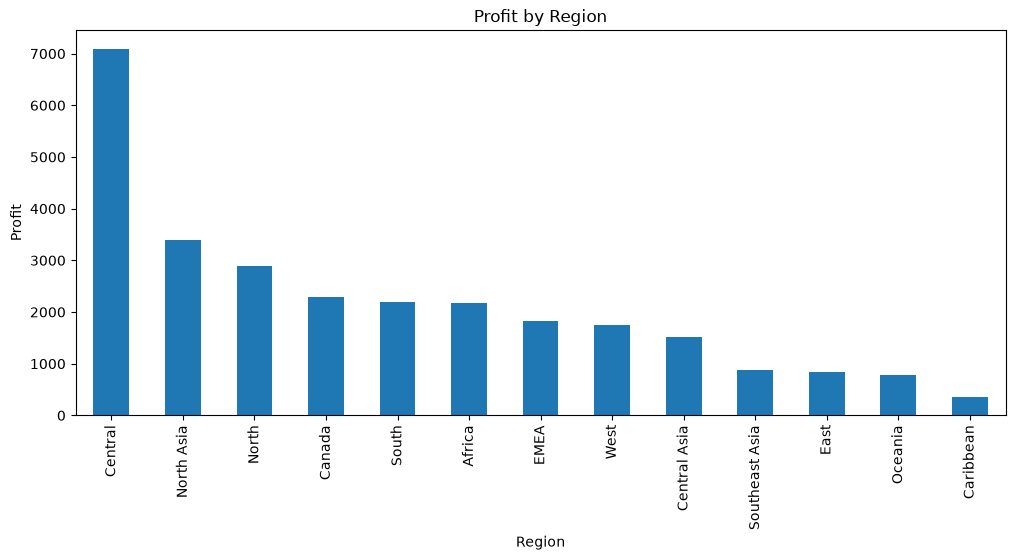

In [43]:
plt.figure(figsize=(12,5))
region_profit.plot(kind='bar')

plt.title("Profit by Region")
plt.xlabel("Region")
plt.ylabel("Profit")

plt.show()

# Sales by Segment


In [44]:
segment_sales= df.groupby('Segment')['Sales'].sum()
segment_sales


Segment
Consumer       128296.89600
Corporate       59768.52844
Home Office     55894.63848
Name: Sales, dtype: float64

# Sales by Customer Segment Graph Plot

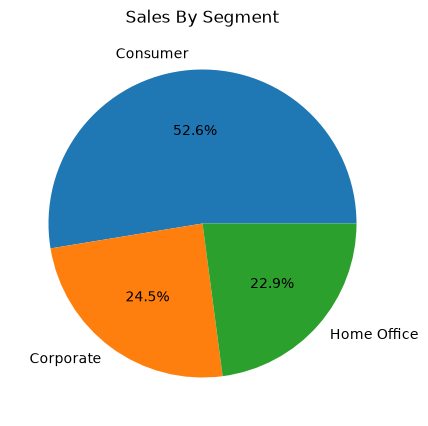

In [48]:
plt.figure(figsize=(12,5))
segment_sales.plot(kind='pie', autopct='%1.1f%%')

plt.title("Sales By Segment")

plt.ylabel("")

plt.show()

# Monthly Sales Trend

In [49]:
df['Year']
df['Month']
df['Month Name']
df['Quarter']

0      3
1      2
2      4
3      2
4      3
      ..
995    4
996    4
997    4
998    3
999    2
Name: Quarter, Length: 1000, dtype: int32

In [50]:
monthly_sales = df.groupby(['Year', 'Month'])['Sales'].sum()
monthly_sales

Year  Month
2011  1         1015.60790
      2         7014.77600
      3         5013.57200
      4         4185.30000
      5         4441.42650
      6         5256.56350
      7         2444.18800
      8         4827.37692
      9         7449.44080
      10        3711.88960
      11        9027.65308
      12        4375.51140
2012  1         1069.01070
      2          983.20940
      3         4051.64260
      4         1579.47690
      5         1748.66456
      6         4791.21900
      7         1314.27600
      8         6857.09860
      9         7363.71400
      10        3348.91040
      11        6474.50900
      12        2252.57276
2013  1         6553.99560
      2         3556.60200
      3         2375.13650
      4         3333.40064
      5         6176.76640
      6         8128.71020
      7         5309.93660
      8         6581.97634
      9         5980.58932
      10        4411.65678
      11        7515.37410
      12       10566.09360
2014  1         

# Monthly Sales Trend Graph Plot

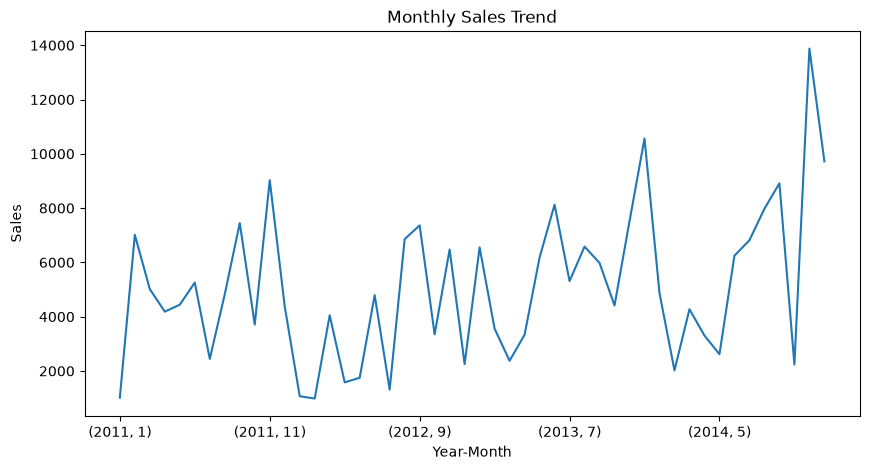

In [51]:
plt.figure(figsize=(10,5))
monthly_sales.plot(kind='line')

plt.title("Monthly Sales Trend")
plt.xlabel("Year-Month")
plt.ylabel("Sales")

plt.show()

# Quartr Sales Analysis


In [52]:
quarter_sales=df.groupby('Quarter')['Sales'].sum()
quarter_sales

Quarter
1    42798.73160
2    51808.93770
3    71833.65680
4    77518.73682
Name: Sales, dtype: float64

# Quartr Sales Analysis Graph Plot


Text(0, 0.5, 'Sales')

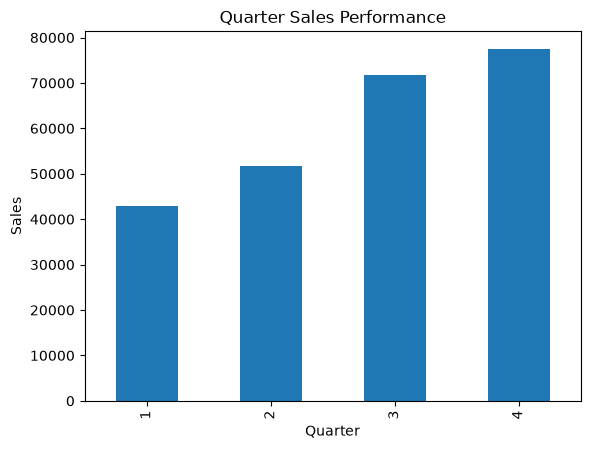

In [53]:
quarter_sales.plot(kind='bar')

plt.title("Quarter Sales Performance")
plt.xlabel("Quarter")
plt.ylabel("Sales")

# Top 10 Products

In [70]:
top_products= df.groupby('Product Name')['Sales'].sum().sort_values(ascending=False).head(10)
top_products

Product Name
Motorola Smart Phone, Full Size                             7083.780
GBC DocuBind P400 Electric Binding System                   5443.960
SAFCO Executive Leather Armchair, Black                     4544.100
Motorola Smart Phone, with Caller ID                        4518.780
Nokia Smart Phone, Full Size                                4247.280
DMI Eclipse Executive Suite Bookcases                       4007.840
Harbour Creations Executive Leather Armchair, Adjustable    3747.906
Sauder Classic Bookcase, Pine                               3498.720
Hamilton Beach Refrigerator, Red                            3000.780
Bush Classic Bookcase, Traditional                          2888.760
Name: Sales, dtype: float64

# Top 10 Products Graph Plot

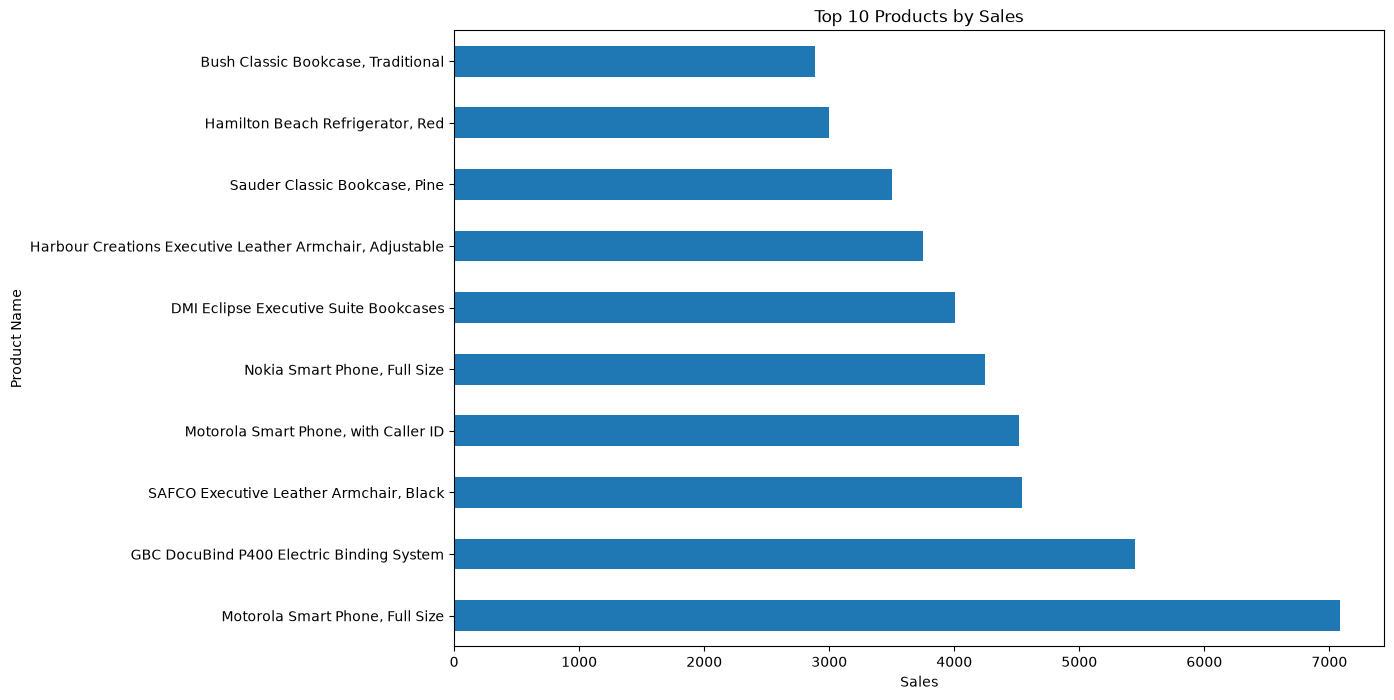

In [71]:
top_products.plot(kind='barh', figsize=(12,8))

plt.title("Top 10 Products by Sales")
plt.xlabel("Sales")

plt.show()


In [69]:
top_products.shape

(827,)

# Key Business Insights

## Sales Performance

- Identified the overall sales performance using total sales, orders, and customer metrics.
- Analyzed the major contributors to revenue across segments, regions, categories, and products.

## Customer Insights

- Identified the customer segment contributing the highest sales.
- Compared purchasing behavior across different customer groups.

## Product Insights

- Identified top-performing products based on sales and profit contribution.
- Evaluated product categories generating maximum revenue.

## Regional Insights

- Compared sales and profitability across different regions.
- Identified regions with strong business performance.

## Profitability Insights

- Analyzed profit distribution and profit margins.
- Identified areas where sales are high but profitability may require improvement.

## Trend Insights

- Observed yearly, monthly, and quarterly sales trends.
- Identified seasonal patterns affecting business performance.

# Conclusion

This Retail Sales & Profit Analytics project demonstrates an end-to-end data analytics workflow, including data understanding, data cleaning, exploratory analysis, and visualization.

The analysis provided insights into sales performance, customer segments, regional contribution, product trends, and profitability. These findings can help businesses make informed decisions, optimize strategies, and improve overall performance.

The project highlights the importance of using data-driven approaches to identify opportunities and solve business problems.